# 02 - System Identification

## Objective

This notebook estimates the parameters of the quadcopter dynamic model using recorded telemetry.

The goals are:

- Load processed telemetry
- Estimate plant parameters
- Build an identified dynamic model
- Simulate the identified model
- Compare measured and simulated responses

This notebook does not perform optimization.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from src.telemetry import TelemetryLoader
from src.processing import SignalProcessor
from src.simulator import IdentifiedModel

plt.style.use("seaborn-v0_8-darkgrid")

## Load Telemetry

In [3]:
loader = TelemetryLoader()

df = loader.load("test_run_01.csv")

processor = SignalProcessor()

df = processor.process_dataframe(df)

Loaded test_run_01.csv: 500 rows @ ~100.0Hz


## Inspect Dataset

In [4]:
df.head()

,dt,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,ax_g,ay_g,az_g,gyroX_dps,gyroY_dps,gyroZ_dps,roll_deg,pitch_deg,yaw_deg
0,0.01,461,744,16113,2181,-3524,626,-0.016747,0.024704,0.952165,16.647686,-26.872577,4.774122,0.035796,0.026288,0.070100
1,0.01,-269,248,16772,-3561,-954,359,-0.028686,-0.087379,0.959178,4.458604,-21.068657,3.178943,0.033729,-0.074445,0.085284
2,0.01,913,994,15389,-2391,1471,-204,0.082345,-0.035078,1.018095,-4.503263,-17.753130,2.028879,0.027614,-0.140239,0.099327
3,0.01,-395,371,15581,312,-3960,-7,-0.091942,0.034551,1.037932,-9.270869,-17.540959,1.576228,0.015691,-0.124268,0.113714
4,0.01,-544,-9,16067,-2133,-6237,314,0.002443,-0.032547,1.001423,-10.749649,-19.375345,1.748292,-0.002511,0.042803,0.131328


## Build Identified Model

Estimate the plant parameters using Least Squares.

In [5]:
model = IdentifiedModel()

model.fit(df)

## Estimated Parameters

In [6]:
model.params_

{'plant_a': 2.741157680098226, 'plant_b': 65.14305295816884, 'plant_c': 0.15}

## Simulate Identified Model

Run the simulator using a sample PID controller.

In [7]:
trajectory = model.run(
    kp=1.5,
    ki=0.2,
    kd=0.4
)

## Measured vs Simulated Pitch

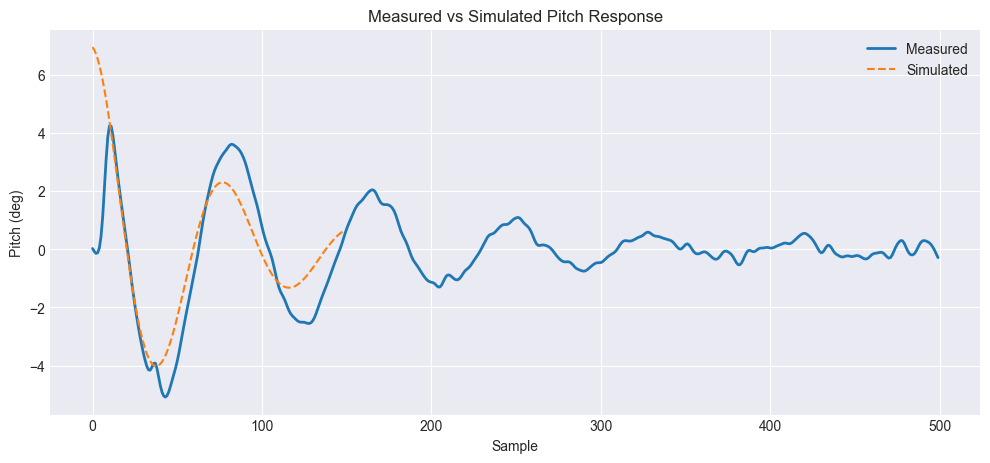

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    df["pitch_deg"],
    label="Measured",
    linewidth=2
)

plt.plot(
    trajectory.pitch,
    label="Simulated",
    linestyle="--"
)

plt.xlabel("Sample")

plt.ylabel("Pitch (deg)")

plt.title("Measured vs Simulated Pitch Response")

plt.legend()

plt.show()

## Simulation Output

In [9]:
print(f"Maximum Pitch : {trajectory.max_pitch:.2f} deg")

print(f"Crashed       : {trajectory.crashed}")

Maximum Pitch : 6.95 deg
Crashed       : False


## Pitch Error

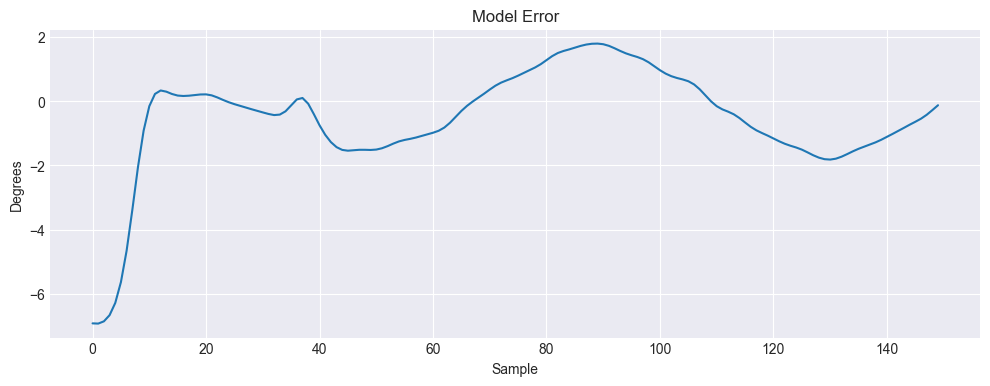

In [10]:
error = df["pitch_deg"].values[:len(trajectory.pitch)] - trajectory.pitch

plt.figure(figsize=(12,4))

plt.plot(error)

plt.title("Model Error")

plt.xlabel("Sample")

plt.ylabel("Degrees")

plt.show()

## Root Mean Square Error (RMSE)

In [11]:
rmse = np.sqrt(np.mean(error**2))

print(f"RMSE = {rmse:.4f} deg")

RMSE = 1.7369 deg


# Conclusion

The identified model approximates the measured system dynamics using parameters estimated from telemetry.

The identified simulator serves as the foundation for optimization in the following notebooks.